In [25]:
import io
import zipfile
import requests
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from matplotlib.backends.backend_pdf import PdfPages

plt.rcParams['figure.dpi'] = 110 # matlib render size ( dots per inch )

# include ','' thousand separator, include one digit after decimal
pd.set_option('display.float_format', lambda x: f'{x:,.1f}')

In [26]:
FORM_D_BASE = "https://www.sec.gov/files/structureddata/data/form-d-data-sets/{q}_d.zip"
QUARTERS = ["2025q2", "2025q3", "2025q4", "2026q1"]

# SEC requires automated requests to identify user agent
HEADERS = {"User-Agent": "wesleyhall2002@gmail.com"}

# open pdf
pdf = PdfPages("infra_saas_vc_analysis.pdf")

In [27]:
def find_entry(z, target_name):
    # find zip with target name, ignore folder dir
    for n in z.namelist():
        if n.lower().endswith(target_name.lower()):
            return n

def fetch_quarter(q):
    # fetch and merge SEC Form D quarterly filings
    url = FORM_D_BASE.format(q=q)
    # make HTTP request
    r = requests.get(url, headers=HEADERS, timeout=60)
    # check for error
    r.raise_for_status()
    # convert bytes to file on ram, open zipped content
    z = zipfile.ZipFile(io.BytesIO(r.content))
    
    # read tsv files
    sub = pd.read_csv(z.open(find_entry(z, "FORMDSUBMISSION.tsv")), sep="\t", low_memory=False)
    off = pd.read_csv(z.open(find_entry(z, "OFFERING.tsv")), sep="\t", low_memory=False)
    iss = pd.read_csv(z.open(find_entry(z, "ISSUERS.tsv")), sep="\t", low_memory=False)

    # left join sub + off on accession number ( unique submission id )
    df = sub.merge(off, on="ACCESSIONNUMBER", how="left")
    # left join df + iss on accession number, drop all duplicate ids, keep initial
    df = df.merge(
        iss[["ACCESSIONNUMBER", "ENTITYNAME", "STATEORCOUNTRY"]].drop_duplicates("ACCESSIONNUMBER"),
        on="ACCESSIONNUMBER", how="left"
    )
    df["quarter"] = q
    return df

In [28]:
# calls fetch quarter per quarter 
# concatenate data frames, separate by index
quarterly = pd.concat([fetch_quarter(q) for q in QUARTERS], ignore_index=True)

In [29]:
# filter tech industries
TECH_INDUSTRIES = {"Other Technology", "Computer Software", "Telecommunications"}
# filter with boolean mask, create data frame copy
tech = quarterly[quarterly["INDUSTRYGROUPTYPE"].isin(TECH_INDUSTRIES)].copy()

# keep only initial filing ( submission type 'D' ) drop amendment rows
tech = tech[tech["SUBMISSIONTYPE"] == "D"].copy()
# drop duplicate ids for multi issuer filings
# creates 1:1 deal to filing relationship
tech = tech.drop_duplicates(subset=["ACCESSIONNUMBER"])

# drop rows where 'TOTALAMOUNTSOLD' could not be converted to numeric val
tech["TOTALAMOUNTSOLD"] = pd.to_numeric(tech["TOTALAMOUNTSOLD"], errors="coerce")
tech = tech.dropna(subset=["TOTALAMOUNTSOLD"])

# key words to match with segment
SEGMENT_KEYWORDS = {
    "DevOps": [
        "dev", "devops", "code", "coding", "build", "pipeline", "deploy",
        "deployment", "test", "testing", "forge", "ship", "ci", "cd",
        "git", "repo", "compiler", "release",
    ],
    "Data Software & Systems": [
        "data", "database", "query", "ledger", "warehouse", "metric",
        "metrics", "analytic", "analytics", "vault", "lake", "etl",
        "pipeline", "stream", "streaming", "iceberg", "schema",
    ],
    "ITOps": [
        "ops", "itops", "monitor", "monitoring", "trace", "tracing",
        "network", "networking", "grid", "sync", "observ", "observability",
        "alert", "incident", "uptime", "log", "logging",
    ],
    "Application Infrastructure": [
        "cloud", "api", "stack", "route", "router", "node", "platform",
        "infra", "infrastructure", "middleware", "gateway", "cdn",
        "serverless", "container", "kubernetes", "microservice",
    ],
}

def classify(name):
    # check for segment key words per entity
    name_l = str(name).lower()
    for segment, kws in SEGMENT_KEYWORDS.items():
        if any(kw in name_l for kw in kws):
            return segment
    # default to 'Application Infastructure'
    return "Application Infrastructure"

# run classify per entity
tech["segment"] = tech["ENTITYNAME"].apply(classify)

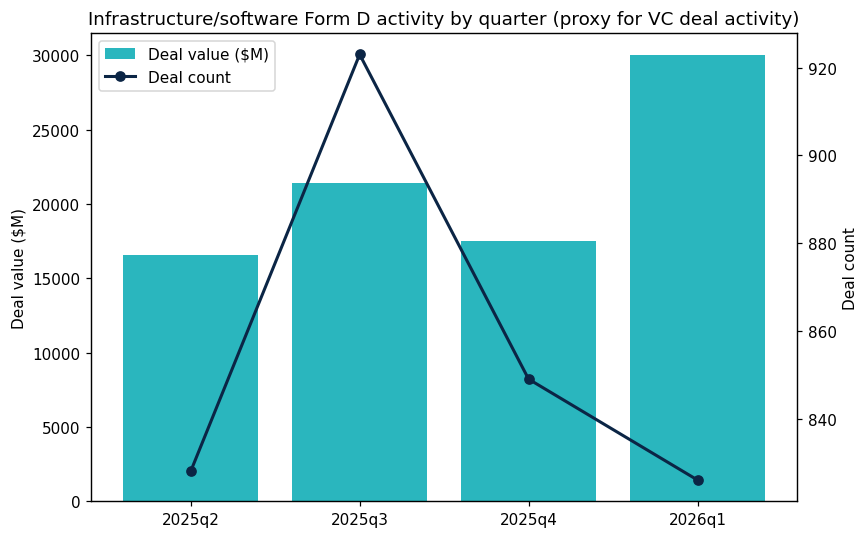

In [30]:
# group by quarter
# sum 'TOTALAMOUNTSOLD', convert to musd
# count deals
# index by quarter
summary = tech.groupby("quarter").agg(
    deal_value_musd=("TOTALAMOUNTSOLD", lambda s: s.sum() / 1_000_000),
    deal_count=("ACCESSIONNUMBER", "count"),
).reindex(QUARTERS)

# create plot and title
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.set_title("Infrastructure/software Form D activity by quarter (proxy for VC deal activity)")

# map axis 1 as deal value ($M)
ax1.bar(summary.index, summary["deal_value_musd"], color="#2AB6BE", label="Deal value ($M)")
ax1.set_ylabel("Deal value ($M)")
ax1.set_title("Infrastructure/software Form D activity by quarter (proxy for VC deal activity)")

# map axis 2 as deal count, overlaying axis 1
ax2 = ax1.twinx()
ax2.plot(summary.index, summary["deal_count"], color="#0B2545", marker="o", linewidth=2, label="Deal count")
ax2.set_ylabel("Deal count")

# merge legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")

plt.tight_layout()
plt.show()

summary

# write to pdf
pdf.savefig(fig)

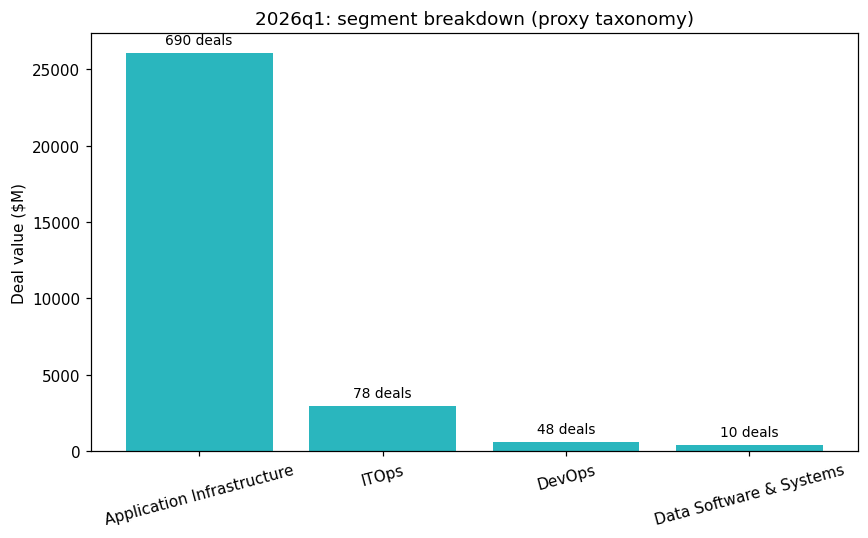

In [31]:
# select most recent quarter
latest_q = QUARTERS[-1]

# group by segment
# sum 'TOTALAMOUNTSOLD', convert to musd
# count deals
# index by desc deal value
seg = tech[tech["quarter"] == latest_q].groupby("segment").agg(
    deal_value_musd=("TOTALAMOUNTSOLD", lambda s: s.sum() / 1_000_000),
    deal_count=("ACCESSIONNUMBER", "count"),
).sort_values("deal_value_musd", ascending=False)

# create plot and title
fig, ax1 = plt.subplots(figsize=(8, 5))
ax1.set_title(f"{latest_q}: segment breakdown (proxy taxonomy)")

# map axis 1 as deal value ($M)
ax1.bar(seg.index, seg["deal_value_musd"], color="#2AB6BE")
ax1.set_ylabel("Deal value ($M)")
plt.xticks(rotation=15)

# iterate through data frame, yield segment name and row data
# enumerate to get integer bar position i
# annotate each bar with its deal count, positioned above bar height
for i, (segn, row) in enumerate(seg.iterrows()):
    ax1.annotate(f"{int(row['deal_count'])} deals", (i, row["deal_value_musd"]),
                 textcoords="offset points", xytext=(0, 6), ha="center", fontsize=9)

plt.tight_layout()
plt.show()

seg

# write to pdf
pdf.savefig(fig)

In [32]:
# copy summary to avoid mutation
qoq = summary.copy()
# get % change deal value and count between quarters
qoq["deal_value_qoq_pct"] = qoq["deal_value_musd"].pct_change() * 100
qoq["deal_count_qoq_pct"] = qoq["deal_count"].pct_change() * 100
# round to one decimal
qoq.round(1)

,deal_value_musd,deal_count,deal_value_qoq_pct,deal_count_qoq_pct
quarter,,,,
2025q2,"16,590.6",828,NaN,NaN
2025q3,"21,441.3",923,29.2,11.5
2025q4,"17,523.1",849,-18.3,-8.0
2026q1,"29,987.8",826,71.1,-2.7


In [33]:
# close pdf
pdf.close()